In [60]:
import torch
import os
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from torchvision import models

In [20]:
root = os.path.dirname(os.path.abspath('main.ipynb'))
dataPth = os.path.join(root, 'data')
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=dataPth, transform=transform)
full_dataset.classes

['cloudy',
 'foggy',
 'lightning',
 'rainbow',
 'rainy',
 'rime',
 'sandstorm',
 'sunrise']

In [21]:
train_dataset_len = int(0.8 * len(full_dataset))
test_dataset_len = len(full_dataset) - train_dataset_len

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_dataset_len, test_dataset_len]
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [22]:
images, labels = next(iter(train_loader))
images

tensor([[[[-1.2788, -1.4329, -1.5870,  ..., -1.6898, -1.6898, -1.6727],
          [-1.3644, -1.4843, -1.5357,  ..., -1.7240, -1.7240, -1.7069],
          [-1.4672, -1.5014, -1.5014,  ..., -1.7240, -1.7240, -1.7069],
          ...,
          [-1.4329, -1.3987, -1.3987,  ..., -1.7925, -1.8097, -1.8439],
          [-1.5014, -1.4843, -1.4329,  ..., -1.8610, -1.8439, -1.8610],
          [-1.5357, -1.5014, -1.3987,  ..., -1.8782, -1.8439, -1.8782]],

         [[-1.1604, -1.1779, -1.2479,  ..., -1.4230, -1.4055, -1.3880],
          [-1.1954, -1.1954, -1.1954,  ..., -1.4580, -1.4405, -1.4230],
          [-1.2129, -1.2304, -1.1779,  ..., -1.4755, -1.4755, -1.4580],
          ...,
          [-0.5651, -0.5476, -0.5651,  ..., -1.0378, -1.0553, -1.1253],
          [-0.7402, -0.7227, -0.6702,  ..., -1.0378, -1.0378, -1.0728],
          [-0.7927, -0.7577, -0.6527,  ..., -1.1078, -1.0903, -1.1253]],

         [[-0.8284, -0.8110, -0.8110,  ..., -1.0376, -1.0376, -1.0550],
          [-0.8110, -0.7936, -

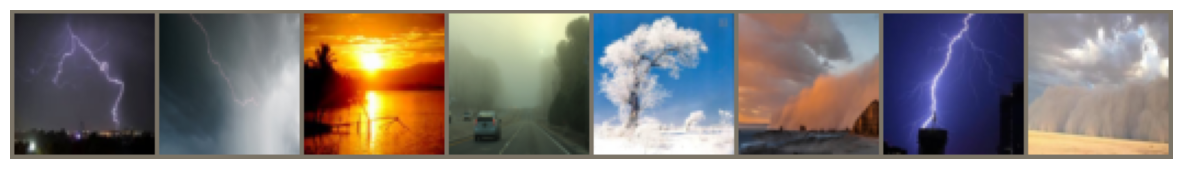

Лейблы:  lightning  | lightning  |  sunrise   |   foggy    |    rime    | sandstorm  | lightning  | sandstorm 


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(15, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

images_to_show = images[:8]
labels_to_show = labels[:8]

imshow(torchvision.utils.make_grid(images_to_show))

classes = full_dataset.classes
print('Лейблы: ', ' | '.join(f'{classes[labels_to_show[j]]:^10s}' for j in range(8)))

In [24]:
class WeatherCNN(nn.Module):
    def __init__(self):
        super(WeatherCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=32*8*8, out_features=len(full_dataset.classes))

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [25]:
model = WeatherCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [26]:
def NN_work(model, criterion, optimizer):
    epochs = 15

    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader:
            optimizer.zero_grad()
            predict = model(images)
            Loss = criterion(predict, labels)
            Loss.backward()
            optimizer.step()
        
        model.eval()

        test_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():
            for images, labels in test_loader:
                predict = model(images)
                predicted_classes = torch.argmax(predict, dim=1)
                Loss = criterion(predict, labels)
                test_loss += Loss.item()
                correct_predictions += (predicted_classes == labels).sum().item()
                total_predictions += labels.size(0)

            avg_test_loss = test_loss/len(test_loader)

            accuracy = (correct_predictions / total_predictions) * 100

            print(f'Эпоха [{epoch+1}/{epochs}], Loss на тесте: {avg_test_loss:.4f}, Точность: {accuracy:.2f}%')



In [27]:
NN_work(model, criterion, optimizer)

Эпоха [1/15], Loss на тесте: 1.5696, Точность: 44.55%
Эпоха [2/15], Loss на тесте: 1.3068, Точность: 51.12%
Эпоха [3/15], Loss на тесте: 1.2093, Точность: 54.81%
Эпоха [4/15], Loss на тесте: 1.1032, Точность: 62.34%
Эпоха [5/15], Loss на тесте: 1.0982, Точность: 61.22%
Эпоха [6/15], Loss на тесте: 1.0338, Точность: 68.43%
Эпоха [7/15], Loss на тесте: 0.9174, Точность: 69.55%
Эпоха [8/15], Loss на тесте: 0.9410, Точность: 68.75%
Эпоха [9/15], Loss на тесте: 0.9810, Точность: 69.55%
Эпоха [10/15], Loss на тесте: 0.9607, Точность: 68.59%
Эпоха [11/15], Loss на тесте: 0.9211, Точность: 72.28%
Эпоха [12/15], Loss на тесте: 1.0445, Точность: 71.96%
Эпоха [13/15], Loss на тесте: 1.2040, Точность: 71.31%
Эпоха [14/15], Loss на тесте: 1.2069, Точность: 67.15%
Эпоха [15/15], Loss на тесте: 1.2057, Точность: 68.11%


Добавим агументацию к тренировочному датасету и dropout в наш скрытый слой

In [31]:
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=dataPth, transform=train_transforms)

test_dataset = ImageFolder(root=dataPth, transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_dataset = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True
)


                

In [32]:
class WeatherCNN(nn.Module):
    def __init__(self):
        super(WeatherCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)#64x64 -> 32->32

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.flatten = nn.Flatten()

        self.dropout = nn.Dropout(p=0.5)

        self.linear = nn.Linear(32*8*8, out_features=len(full_dataset.classes))

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear(x)
        return x


In [33]:
model = WeatherCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [34]:
NN_work(model, criterion, optimizer)

Эпоха [1/15], Loss на тесте: 1.2859, Точность: 59.46%
Эпоха [2/15], Loss на тесте: 0.9815, Точность: 64.58%
Эпоха [3/15], Loss на тесте: 0.8031, Точность: 74.36%
Эпоха [4/15], Loss на тесте: 0.7230, Точность: 75.16%
Эпоха [5/15], Loss на тесте: 0.7852, Точность: 72.76%
Эпоха [6/15], Loss на тесте: 0.6316, Точность: 78.37%
Эпоха [7/15], Loss на тесте: 0.6076, Точность: 79.81%
Эпоха [8/15], Loss на тесте: 0.6141, Точность: 78.21%
Эпоха [9/15], Loss на тесте: 0.5621, Точность: 78.37%
Эпоха [10/15], Loss на тесте: 0.6262, Точность: 76.60%
Эпоха [11/15], Loss на тесте: 0.5529, Точность: 82.05%
Эпоха [12/15], Loss на тесте: 0.4610, Точность: 83.65%
Эпоха [13/15], Loss на тесте: 0.4889, Точность: 82.37%
Эпоха [14/15], Loss на тесте: 0.3808, Точность: 87.66%
Эпоха [15/15], Loss на тесте: 0.4484, Точность: 85.58%


In [57]:
def printCycle(single_image, true_label):
    model.eval()
    with torch.no_grad():
        img_display = single_image.squeeze().numpy().transpose((1, 2, 0))
    
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        
        img_display = np.clip(img_display, 0, 1)


        out_conv1 = model.conv1(single_image)
        out_conv1 = model.bn1(out_conv1)
        out_conv1 = model.relu(out_conv1)
        out_pool1 = model.pool(out_conv1)

        out_conv2 = model.conv2(out_pool1)
        out_conv2 = model.bn2(out_conv2)
        out_conv2 = model.relu(out_conv2)
        out_pool2 = model.pool(out_conv2)

        out_conv3 = model.conv3(out_pool2)
        out_conv3 = model.bn3(out_conv3)
        out_conv3 = model.relu(out_conv3)
        out_pool3 = model.pool(out_conv3)
        
        out_flat = model.flatten(out_pool3)
        out_drop = model.dropout(out_flat)

        logits = model.linear(out_drop)
        
        probabilities = F.softmax(logits, dim=1).squeeze().numpy() * 100

    fig = plt.figure(figsize=(15, 12))

    ax_main = fig.add_subplot(3, 1, 1)
    ax_main.imshow(img_display)
    ax_main.set_title(f"Входное изображение (Истинный класс: {classes[true_label]})", fontsize=14)
    ax_main.axis('off')

    features1 = out_pool1.squeeze().numpy()
    for i in range(8):
        ax = fig.add_subplot(4, 8, 8 + i + 1)
        ax.imshow(features1[i]) 
        ax.axis('off')
        if i == 3: ax.set_title("Слой 1", fontsize=12)

    features2 = out_pool2.squeeze().numpy()
    for i in range(8):
        ax = fig.add_subplot(4, 8, 16 + i + 1)
        ax.imshow(features2[i])
        ax.axis('off')
        if i == 3: ax.set_title("Слой 2", fontsize=12)

        
    features3 = out_pool3.squeeze().numpy()
    for i in range(8):
        ax = fig.add_subplot(4, 8, 24 + i + 1)
        ax.imshow(features3[i])
        ax.axis('off')
        if i == 3: ax.set_title("Слой 3", fontsize=12)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(classes, probabilities, color='skyblue', edgecolor='black')
    plt.title("Уверенность нейросети по классам (%)", fontsize=14)
    plt.ylabel("Вероятность (%)")
    plt.ylim(0, 100)
    for i, v in enumerate(probabilities):
        if v > 1:
            plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
    plt.show()

/tmp/ipykernel_20411/413319156.py:64: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout()


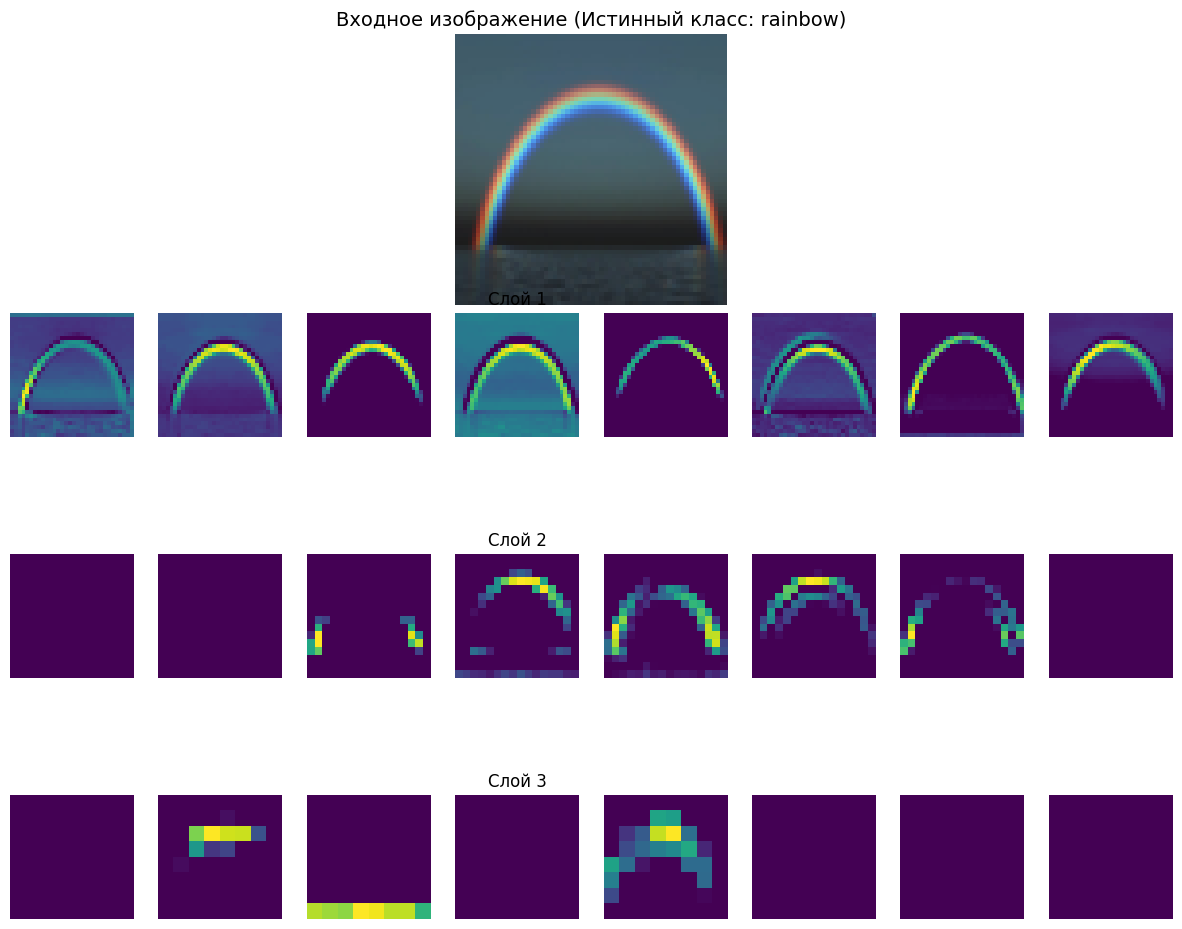

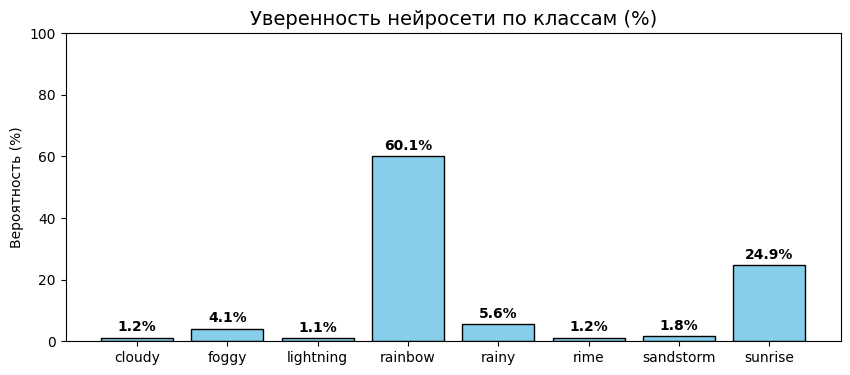

In [59]:
images, labels = next(iter(test_dataset))
single_image = images[0].unsqueeze(0)
true_label = labels[0].item()
printCycle(single_image, true_label)

Перейдём к использованию Resnet

In [61]:
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:18<00:00, 2.48MB/s]


In [62]:
for param in model.parameters():
    param.requires_grad = False

num_classes = len(full_dataset.classes)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

for param in model.fc.parameters():
    param.requires_grad = True

In [63]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=dataPth, transform=train_transforms)
test_dataset = ImageFolder(root=dataPth, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [ ]:
optimizer = optim.Adam([
    {'params': model.fc.parameters(), 'lr': 1e-3},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.layer3.parameters(), 'lr': 1e-5},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)

criterion = nn.CrossEntropyLoss()

In [67]:
def train_model(model, train_loader, test_loader, optimizer, scheduler, epochs=50):
    train_losses = []
    test_accuracies = []
    best_accuracy = 0.0
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if batch_idx % 20 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        
        scheduler.step(avg_train_loss)
        
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.2f}%')
        
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), 'best_resnet_model.pth')
            print(f'✓ Model saved with accuracy: {accuracy:.2f}%')
    
    return train_losses, test_accuracies

In [ ]:
train_model(model, train_loader, test_loader, optimizer, scheduler, epochs=50)

Epoch 1/50, Batch 0, Loss: 1.0343
Epoch 1/50, Batch 20, Loss: 1.1213
Epoch 1/50, Batch 40, Loss: 1.1800
Epoch 1/50, Batch 60, Loss: 0.8626
Epoch 1/50, Batch 80, Loss: 0.9405
Epoch 1/50, Loss: 0.9064, Accuracy: 86.91%
✓ Model saved with accuracy: 86.91%
Epoch 2/50, Batch 0, Loss: 0.7778
Epoch 2/50, Batch 20, Loss: 0.5844
Epoch 2/50, Batch 40, Loss: 0.6537
Epoch 2/50, Batch 60, Loss: 0.5478
Epoch 2/50, Batch 80, Loss: 0.9426
Epoch 2/50, Loss: 0.7294, Accuracy: 86.97%
✓ Model saved with accuracy: 86.97%
Epoch 3/50, Batch 0, Loss: 0.6081
Epoch 3/50, Batch 20, Loss: 0.8219
Epoch 3/50, Batch 40, Loss: 0.5376
Epoch 3/50, Batch 60, Loss: 0.6842
Epoch 3/50, Batch 80, Loss: 0.5966
Epoch 3/50, Loss: 0.6578, Accuracy: 88.03%
✓ Model saved with accuracy: 88.03%
Epoch 4/50, Batch 0, Loss: 0.5241
Epoch 4/50, Batch 20, Loss: 0.7399
Epoch 4/50, Batch 40, Loss: 0.9650
Epoch 4/50, Batch 60, Loss: 0.5693
Epoch 4/50, Batch 80, Loss: 0.3244
Epoch 4/50, Loss: 0.6219, Accuracy: 90.85%
✓ Model saved with accur